# EDA & Baseline Model
**Objective:** To clean the raw dataset, perform Exploratory Data Analysis (EDA) to understand the factors influencing UAE car prices, and establish a baseline prediction model using Linear Regression.

## 1. Environment Setup & Library Imports
In this section, we import the necessary libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Data Loading & Initial EDA
We begin by loading the raw dataset and inspecting the available features and missing values.

In [4]:
# Load the new dataset
df = pd.read_csv('../data/data.csv')

print(f"Initial Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

print("--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

Initial Dataset Shape: 9970 rows and 20 columns.

--- Missing Values ---
title                5
no_of_cylinders     81
year               970
motors_trim         28
dtype: int64


## 2. Data Cleaning
To ensure our Linear Regression model receives quality data, we will:
1. Drop unstructured text (`title`, `date_posted`).
2. Force numeric types to catch hidden string errors.
3. Drop rows missing critical targets (`year`, `price_in_aed`, `kilometers`).
4. Fill minor missing values with logical defaults (Mode for cylinders, 'Unknown' for trims).
5. Apply logical boundaries (Cap prices at AED 500,000 and kilometers at 500,000).

In [5]:
# Drop useless columns
df = df.drop(columns=['title', 'date_posted'])

# Fix data types
df['no_of_cylinders'] = pd.to_numeric(df['no_of_cylinders'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['price_in_aed'] = pd.to_numeric(df['price_in_aed'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['kilometers'] = pd.to_numeric(df['kilometers'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['year'] = pd.to_numeric(df['year'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Drop rows with critical missing data
df = df.dropna(subset=['year', 'price_in_aed', 'kilometers'])

# Fill minor missing data
df['no_of_cylinders'] = df['no_of_cylinders'].fillna(df['no_of_cylinders'].mode()[0])
df['motors_trim'] = df['motors_trim'].fillna('Unknown')
df['regional_specs'] = df['regional_specs'].fillna('Unknown')

# Cap Outliers
df_clean = df[(df['price_in_aed'] >= 5000) & (df['price_in_aed'] <= 500000)].copy()
df_clean = df_clean[df_clean['kilometers'] <= 500000]

print(f"Cleaned Dataset Shape: {df_clean.shape[0]} rows.")

Cleaned Dataset Shape: 8316 rows.


## 3. Feature Engineering
We will create two highly linear features that represent real-world vehicle depreciation:
1. **Age:** The current year minus the manufacture year.
2. **Km_per_Year:** The intensity of the vehicle's usage over its lifetime.
3. **Horsepower Mapping:** Convert the categorical horsepower bins (e.g., "200 - 300 HP") into numerical averages (e.g., 250) so the Linear Regression model can mathematically weigh engine power. 'Unknown' values will be imputed with the dataset's median.

In [6]:
# Calculate Age
current_year = datetime.now().year
df_clean['age'] = current_year - df_clean['year']

# Calculate Km per Year (replace 0 age with 1 to avoid division errors on brand new cars)
df_clean['km_per_year'] = df_clean['kilometers'] / df_clean['age'].replace(0, 1)

# Horsepower Mapping
hp_mapping = {
    'Less than 150 HP': 125,
    '150 - 200 HP': 175,
    '200 - 300 HP': 250,
    '300 - 400 HP': 350,
    '400 - 500 HP': 450,
    '500 - 600 HP': 550,
    '600 - 700 HP': 650,
    '700 - 800 HP': 750,
    '800 - 900 HP': 850,
    '900+ HP': 950
}

# Map the strings to our numbers ('Unknown' automatically becomes NaN)
df_clean['horsepower'] = df_clean['horsepower'].map(hp_mapping)

# Fill the newly created NaNs ('Unknowns') with the median horsepower of the dataset
df_clean['horsepower'] = df_clean['horsepower'].fillna(df_clean['horsepower'].median())

df_clean[['year', 'age', 'kilometers', 'km_per_year', 'horsepower']].head(3)

,year,age,kilometers,km_per_year,horsepower
0,2013.0,13.0,167390,12876.153846,250.0
1,2018.0,8.0,39000,4875.000000,450.0
2,2014.0,12.0,200000,16666.666667,450.0


In [7]:
df_clean.to_csv('../data/ui_car_tree_data.csv', index=False)

## 4. Categorical Encoding
Linear Regression cannot process English text. We will use standard One-Hot Encoding to convert all categorical features (like Make, Model, Condition, and Trim) into binary columns. We use `drop_first=True` to avoid the dummy variable trap (multicollinearity).

In [8]:
categorical_cols = [
    'body_condition', 'mechanical_condition', 'seller_type', 'body_type', 
    'transmission_type', 'regional_specs', 'fuel_type', 'steering_side', 
    'color', 'emirate', 'motors_trim', 'company', 'model'
]

cols_to_encode = [col for col in categorical_cols if col in df_clean.columns]
df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

# Export the encoded dataset
df_encoded.to_csv("../data/dubizzle_cleaned.csv", index=False)

print(f"Encoded Dataset Shape: {df_encoded.shape[1]}")

Encoded Dataset Shape: 1436


## 5. Train/Validation/Test Split
We will split the data as follows: 
* **70% Training** (To train the model)
* **15% Validation** (To tune hyperparameters later)
* **15% Testing** (To evaluate final performance)

In [9]:
X = df_encoded.drop(columns=['price_in_aed'])
y = df_encoded['price_in_aed']

# Train/Temp Split (70% Train, 30% Temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Temp into Validation/Test (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

## 6. Baseline Model: Linear Regression
We will train a standard Linear Regression model to establish a baseline. All subsequent models built by the team (Random Forest, XGBoost, etc.) must beat this baseline performance.

We will evaluate the model using:
* **RMSE (Root Mean Squared Error):** The average error in AED.
* **MAE (Mean Absolute Error):** The absolute average error in AED.
* **R^2 Score:** The proportion of variance in the price that our model explains.

In [10]:
# Initialize and Train Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_test = lr_model.predict(X_test)

# Evaluate
print("--- FINAL LINEAR REGRESSION (Test Set) ---")
print(f"RMSE: AED {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"MAE:  AED {mean_absolute_error(y_test, y_pred_test):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")

--- FINAL LINEAR REGRESSION (Test Set) ---
RMSE: AED 49,153.81
MAE:  AED 32,111.91
R²:   0.7523


## 7. Model Visual Evaluation
To truly understand our model's performance beyond static metrics, we visualize its predictions:
1. **Actual vs Predicted:** A perfect model would plot all points exactly on the red dashed line. Points below the line mean the model is underpricing the car; points above mean it is overpricing.
2. **Learning Curve:** Evaluates if the model is suffering from high bias (underfitting) or high variance (overfitting) by tracking the error as we feed it more training data.

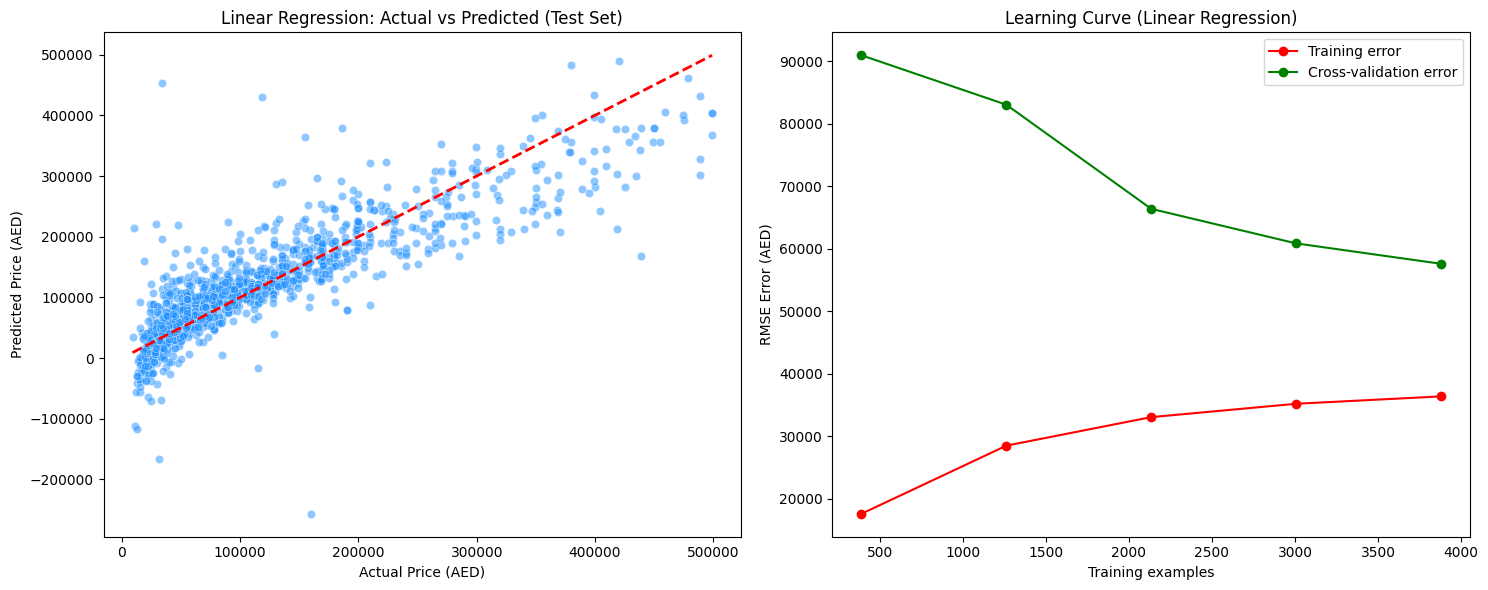

In [11]:
plt.figure(figsize=(15, 6))

# 1. Actual vs Predicted Scatter Plot
plt.subplot(1, 2, 1)
# We use an alpha of 0.5 so we can see where points overlap heavily
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5, color='dodgerblue')
# Draw the prediction baseline (Red dashed line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title('Linear Regression: Actual vs Predicted (Test Set)')

# 2. Learning Curve
plt.subplot(1, 2, 2)
# Calculate training and validation errors at different sample sizes
train_sizes, train_scores, test_scores = learning_curve(
    lr_model, X_train, y_train, cv=3, scoring='neg_mean_squared_error', 
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1)

# Convert negative MSE back to RMSE for readability
train_scores_mean = np.sqrt(-train_scores.mean(axis=1))
test_scores_mean = np.sqrt(-test_scores.mean(axis=1))

# Plot the curves
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training error")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation error")
plt.xlabel("Training examples")
plt.ylabel("RMSE Error (AED)")
plt.title("Learning Curve (Linear Regression)")
plt.legend(loc="best")

plt.tight_layout()
plt.show()